In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
main_path = '/Users/Kai/HPL-LATTICeA/'
import os
import sys
sys.path.append(main_path)

In [3]:
metadata_subset = pd.read_csv(os.path.join(main_path, 'analysis/rnaseq/metadata_subset_temposeq.csv'), index_col=0)
hallmarks_ssgsea = pd.read_csv(os.path.join(main_path, 'analysis/rnaseq/hallmarks_ssgsea_df.csv'), index_col=0)

/Users/Kai/miniconda3/envs/scpy_310/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/Kai/miniconda3/envs/scpy_310/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


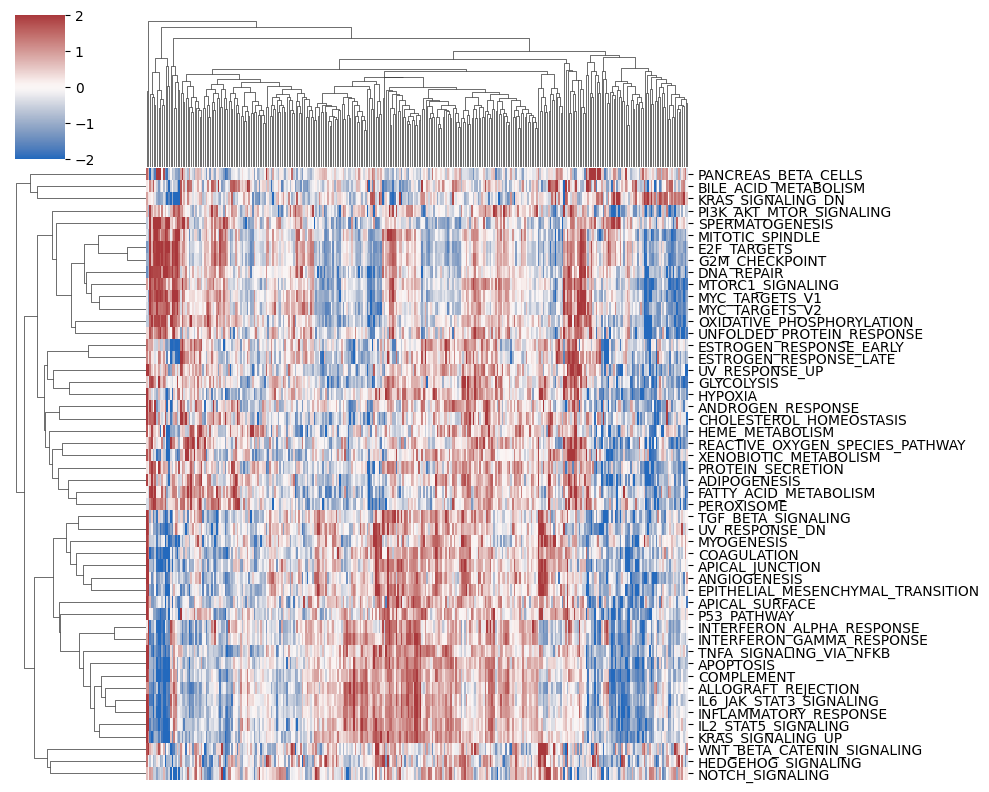

In [4]:
sns.clustermap(hallmarks_ssgsea,
               z_score=0,
               vmin=-2, vmax=2,
               cmap='vlag',
               yticklabels=1,
               xticklabels=0,
               figsize=(10,8))

In [5]:
id_dict = metadata_subset['core_id'].to_dict()

In [6]:
hallmarks_ssgsea_t = hallmarks_ssgsea.T.reset_index(names='ts')
hallmarks_ssgsea_t = hallmarks_ssgsea_t.merge(metadata_subset.reset_index(names='ts')[['ts', 'supercluster']], on='ts').set_index('ts')
hallmarks_ssgsea_t = hallmarks_ssgsea_t.replace({'Hot discohesive (low risk)':'Hot discohesive\n(low risk)', 'Hot discohesive (high risk)':'Hot discohesive\n(high risk)'})
hallmarks_ssgsea_t

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM,supercluster
ts,,,,,,,,,,,,,,,,,,,,,
2A_296,0.398468,0.322784,0.469573,0.327995,0.311204,0.187650,0.438748,0.085906,0.400452,0.287677,...,0.421583,-0.162153,0.542684,0.524925,0.529303,0.419054,0.294892,0.218378,0.270750,Hot discohesive\n(low risk)
2B_90,0.434947,0.174592,0.501731,0.376232,0.362821,0.212636,0.451900,0.069228,0.455044,0.324844,...,0.450806,-0.146599,0.561905,0.393681,0.537181,0.434486,0.303244,0.320189,0.249142,Cold discohesive
2C_40,0.375585,0.271245,0.497840,0.397551,0.344441,0.199173,0.466209,0.082242,0.388468,0.334646,...,0.465974,-0.146689,0.560567,0.464227,0.523902,0.466084,0.275157,0.242883,0.247401,Cold discohesive
2F_96,0.422818,0.275466,0.511412,0.400619,0.351492,0.166666,0.467012,0.096436,0.406622,0.358920,...,0.463788,-0.114815,0.549298,0.411691,0.502989,0.452314,0.301971,0.289743,0.269615,Cold discohesive
3E_192,0.422685,0.318778,0.514945,0.378736,0.341956,0.128321,0.460239,0.052845,0.461810,0.328613,...,0.508270,-0.141616,0.514006,0.498341,0.567367,0.423627,0.298971,0.249358,0.248904,Cold discohesive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10E_1088,0.410067,0.122709,0.517119,0.221596,0.256060,0.075125,0.418953,0.136240,0.387580,0.221817,...,0.411360,-0.105727,0.473487,0.323024,0.510544,0.393295,0.277989,0.224685,0.222438,Cold cohesive
10J_1112,0.437831,0.226730,0.492722,0.308222,0.259677,0.149420,0.434653,0.102739,0.384095,0.301406,...,0.558423,-0.073638,0.483156,0.439379,0.560591,0.365000,0.349848,0.252025,0.334899,Cold discohesive
13D_1085,0.429094,0.198131,0.469947,0.400825,0.314359,0.143023,0.435503,0.093096,0.398139,0.288556,...,0.495577,-0.117331,0.516719,0.408200,0.512879,0.406404,0.284488,0.333299,0.250364,Cold discohesive


In [7]:
pathways = [col for col in hallmarks_ssgsea_t.columns if col not in ['supercluster']]

In [8]:
hallmarks_ssgsea_t['supercluster'].value_counts()

supercluster
Cold cohesive                   100
Hot cohesive                     76
Hot discohesive\n(low risk)      65
Cold discohesive                 63
Hot discohesive\n(high risk)     13
Name: count, dtype: int64

In [9]:
from scipy import stats

groups = [hallmarks_ssgsea_t[hallmarks_ssgsea_t['supercluster'] == g][pathways] for g in hallmarks_ssgsea_t['supercluster'].unique()]
stat, p_levene = stats.levene(*groups)
p_levene

array([2.79709620e-01, 4.73859072e-01, 6.36814955e-01, 4.96977534e-01,
       1.64140381e-02, 6.54128273e-01, 5.84563457e-01, 6.97719650e-01,
       4.57114304e-01, 1.87411952e-01, 2.17450722e-01, 3.55725890e-01,
       1.20093050e-01, 9.45955304e-02, 1.29043117e-02, 1.37514582e-01,
       1.61009399e-01, 7.45077416e-02, 3.31884748e-01, 3.32826023e-01,
       4.67912038e-01, 5.16922739e-02, 8.51127825e-01, 8.67555077e-01,
       4.20995685e-01, 1.64951874e-02, 2.35417762e-01, 4.80859752e-01,
       8.17029241e-01, 4.14147655e-01, 5.92935883e-01, 5.12528646e-01,
       4.23257338e-01, 6.80677184e-01, 4.40115623e-01, 8.51769698e-01,
       3.64393546e-01, 5.87769167e-05, 6.28606516e-01, 2.46472968e-01,
       9.03722593e-01, 9.52719170e-02, 1.65202410e-02, 6.68792891e-01,
       9.15272181e-02, 6.85569959e-01, 6.63601799e-01, 6.14642753e-01,
       2.21906848e-04, 1.62823513e-02])

In [10]:

f_stat, p_val = stats.f_oneway(
    hallmarks_ssgsea_t[hallmarks_ssgsea_t['supercluster'] == 'Cold cohesive'][pathways],
    hallmarks_ssgsea_t[hallmarks_ssgsea_t['supercluster'] == 'Hot cohesive'][pathways],
    hallmarks_ssgsea_t[hallmarks_ssgsea_t['supercluster'] == 'Hot discohesive\n(low risk)'][pathways],
    hallmarks_ssgsea_t[hallmarks_ssgsea_t['supercluster'] == 'Cold discohesive'][pathways],
    hallmarks_ssgsea_t[hallmarks_ssgsea_t['supercluster'] == 'Hot discohesive\n(high risk)'][pathways]
)

print(p_val)

[1.67892349e-01 9.20834456e-32 2.14018065e-03 5.56759194e-14
 2.84367566e-14 5.18704103e-07 3.85012626e-15 1.04611433e-04
 1.26710555e-01 3.25916753e-12 2.72164900e-15 1.93439699e-06
 8.35831073e-11 4.71862306e-22 2.21805167e-07 1.86046266e-03
 2.61709725e-04 1.94429829e-10 8.33161889e-08 1.00042299e-03
 1.80170642e-01 5.99630739e-10 8.57423266e-19 4.13737821e-22
 3.54643908e-21 6.19498889e-09 1.18147680e-19 5.87087710e-05
 1.48924623e-16 5.22722950e-08 1.61814378e-07 1.06910220e-09
 5.83014457e-07 1.06780043e-08 4.46780496e-07 9.30571869e-06
 2.24881578e-04 1.86985189e-01 9.41721154e-07 3.72235826e-03
 3.72795739e-04 3.16623689e-03 7.35981451e-06 1.48309102e-08
 5.55344743e-12 1.43943535e-04 1.02126265e-12 2.34036229e-01
 2.97037744e-02 6.70773348e-01]


In [11]:
def enrichment_test_by_phenotype(data, phenotype_cols, meta_col, p_th=0.05):
    results = list()

    for group in data[meta_col].unique():
        for phenotype in phenotype_cols:
            positive_group = data[data[meta_col] == group][phenotype].values
            negative_group = data[data[meta_col] != group][phenotype].values
            t_statistic, p_value = stats.ttest_ind(positive_group, negative_group, equal_var=False)

            results.append({
                'Supercluster':group,
                'marker':phenotype,
                't_statistic':t_statistic,
                'p_val': p_value
            })

    results = pd.DataFrame(results)

    results['p_adj'] = stats.false_discovery_control(results['p_val'], method='bh')
    change_data = results.pivot(index='Supercluster', columns='marker', values='t_statistic')
    pval_data = results.pivot(index='Supercluster', columns='marker', values='p_adj')

    significant_mask = pval_data < p_th
    annot_text = change_data.applymap('{:.2f}'.format)
    annot_text = annot_text.mask(significant_mask, '*')
    annot_text = annot_text.mask(~significant_mask, ' ')

    return change_data, annot_text, results

In [12]:
change_data, annot_text, results = enrichment_test_by_phenotype(hallmarks_ssgsea_t, phenotype_cols=pathways, meta_col='supercluster')

/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_22495/2037890915.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = change_data.applymap('{:.2f}'.format)


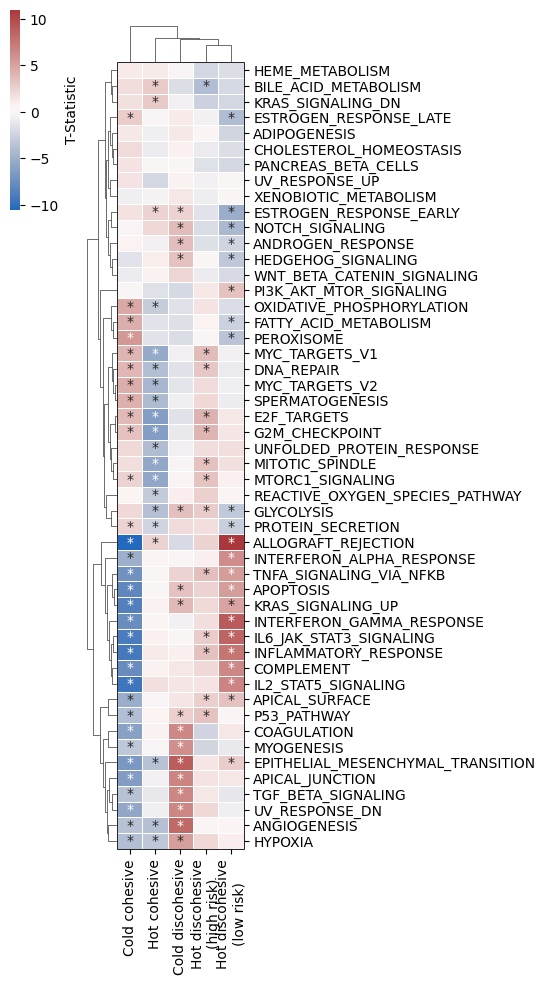

In [13]:
from matplotlib.patches import Rectangle

g = sns.clustermap(change_data.T,
               cmap='vlag',
               annot=annot_text.T,
               fmt='.2s',
               linewidth=.6,
               dendrogram_ratio=(.2, .045), 
               colors_ratio=(0.05,0.07),
               cbar_pos=(-0.12, 0.80, 0.02, 0.2), 
               cbar_kws={'label':'T-Statistic'},
               yticklabels=1,
               xticklabels=1,
               figsize=(5,10))

g.ax_heatmap.collections[0].set_edgecolor('white')
# g.ax_heatmap.collections[0].set_linewidth(.1)

n_rows, n_cols = change_data.T.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=.6,
    clip_on=False
)
g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.set_xlabel(None)

pathways_order = g.dendrogram_row.reordered_ind

plt.savefig(os.path.join(main_path, 'analysis/rnaseq/LATTICeA_hallmarks.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

### TCGA

In [14]:
# tcga_rep_df = pd.read_csv(os.path.join(main_path, 'data/cohesion-superclusters/additional_sample_rep_cox.csv'), index_col=0)
from libraries.data_processing import read_csvs_forcefold, generate_frequency_vector, load_topography
from libraries.supercluster_dictionary import assign_supercluster

h5_complete_path   = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_LATTICeA_5x_he_complete_filtered.h5')
h5_additional_path = os.path.join(main_path, 'results/BarlowTwins_3/LATTICeA_5x/h224_w224_n3_zdim128_filtered/hdf5_TCGA_LUAD_5x_he_train_filtered.h5')
leiden_clusters, malignant_clusters, stromal_clusters = load_topography(main_path=main_path)
complete_df, additional_df, leiden_clusters = read_csvs_forcefold(adatas_path=os.path.join(main_path, 'data/vanilla-hpc'), groupby='leiden_2.5', h5_complete_path=h5_complete_path, h5_additional_path=h5_additional_path, force_fold=2)

additional_sample_rep_cox = generate_frequency_vector(additional_df, matching_field='samples', groupby='leiden_2.5', leiden_clusters=list(malignant_clusters)+[16], transform=True)
additional_melt =  pd.melt(additional_sample_rep_cox, id_vars='samples', value_vars=list(malignant_clusters)+[16], var_name='cluster', value_name='perc')
additional_melt['supercluster'] = additional_melt['cluster'].apply(lambda x: assign_supercluster(f'HPC {x}'))
additional_melt = additional_melt[additional_melt['supercluster'] != 'Unknown']

Sample: TCGA-38-7271 - 0 tiles. Skipping
Sample: TCGA-55-6712 - 0 tiles. Skipping
Sample: TCGA-MP-A4T9 - 0 tiles. Skipping
Sample: TCGA-05-4245 - 0 tiles. Skipping
Sample: TCGA-49-AAR4 - 0 tiles. Skipping


In [15]:
tcga_rep_df = pd.pivot_table(additional_melt, values='perc', index=['samples'], columns='supercluster', aggfunc='sum')
tcga_rep_df

supercluster,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)"
samples,,,,,
TCGA-05-4250,3.367475,-1.750538,-1.065851,-1.268949,5.450559
TCGA-05-4382,-2.658130,0.626596,-3.473701,2.055745,11.881892
TCGA-05-4396,0.561612,-5.511588,2.233145,-1.065554,-3.752887
TCGA-05-4398,-1.272563,-4.115978,2.659374,-1.303408,3.901663
TCGA-05-4402,8.971970,1.000794,-1.609760,-1.353783,-5.820354
...,...,...,...,...,...
TCGA-NJ-A55O,-6.798068,-8.537535,8.273212,-1.422923,2.966509
TCGA-NJ-A55R,3.682602,-2.427294,-0.082256,1.189838,3.972421
TCGA-NJ-A7XG,-2.847957,-2.441106,-1.627404,-0.406851,9.357574


In [16]:
tcga_hallmarks = pd.read_csv(os.path.join(main_path, 'analysis/rnaseq/TCGA/HALLMARKS_ssGSEA_TCGA.csv'), index_col=0)
tcga_hallmarks

,TCGA-05-4244,TCGA-05-4249,TCGA-05-4250,TCGA-05-4382,TCGA-05-4384,TCGA-05-4389,TCGA-05-4390,TCGA-05-4395,TCGA-05-4396,TCGA-05-4397,...,TCGA-NJ-A4YG,TCGA-NJ-A4YI,TCGA-NJ-A4YP,TCGA-NJ-A4YQ,TCGA-NJ-A55A,TCGA-NJ-A55O,TCGA-NJ-A55R,TCGA-NJ-A7XG,TCGA-O1-A52J,TCGA-S2-AA1A
ADIPOGENESIS,0.928286,0.896569,0.921060,0.899685,0.935836,0.932229,0.914731,0.931624,0.904812,0.943202,...,0.912926,0.908623,0.917188,0.895113,0.886160,0.932864,0.916373,0.900491,0.922387,0.888614
ALLOGRAFT_REJECTION,0.758596,0.774225,0.811787,0.803397,0.725012,0.819119,0.721721,0.775893,0.709878,0.728417,...,0.764194,0.722506,0.763217,0.831268,0.779095,0.749610,0.670091,0.673993,0.760600,0.823449
ANDROGEN_RESPONSE,0.958890,0.969981,0.979769,0.959361,0.973172,0.967499,0.969808,0.965398,0.981082,0.946685,...,0.960707,0.930435,0.944144,0.959362,0.964857,0.976215,0.937551,0.964974,0.952013,0.969544
ANGIOGENESIS,0.873057,0.862654,0.924095,0.912679,0.848590,0.831598,0.880105,0.826926,0.843106,0.797044,...,0.895278,0.887547,0.898629,0.779276,0.841063,0.837521,0.900991,0.800166,0.810305,0.895431
APICAL_JUNCTION,0.832725,0.842537,0.856673,0.855841,0.835126,0.825116,0.813131,0.815090,0.801838,0.790719,...,0.825948,0.844010,0.832467,0.812878,0.853257,0.830722,0.823027,0.812855,0.842994,0.855507
APICAL_SURFACE,0.684242,0.685186,0.749270,0.720594,0.702582,0.694021,0.662010,0.692460,0.662802,0.724814,...,0.683252,0.666186,0.707542,0.712396,0.721078,0.710989,0.666755,0.682576,0.701883,0.748665
APOPTOSIS,0.933938,0.925849,0.965988,0.944402,0.921399,0.927168,0.906302,0.941176,0.897302,0.897915,...,0.943202,0.932297,0.930999,0.924738,0.926803,0.926121,0.905023,0.913874,0.935555,0.949101
BILE_ACID_METABOLISM,0.667476,0.652623,0.632194,0.625182,0.688622,0.704406,0.644122,0.626001,0.696000,0.687898,...,0.690096,0.683803,0.643840,0.664117,0.687733,0.688809,0.710696,0.641191,0.699806,0.668891
CHOLESTEROL_HOMEOSTASIS,0.936705,0.896652,0.916162,0.930525,0.899918,0.920739,0.942180,0.909227,0.929987,0.934618,...,0.920711,0.908795,0.949505,0.910560,0.878605,0.933983,0.885435,0.915442,0.908966,0.916945
COAGULATION,0.741548,0.731706,0.762141,0.764814,0.763087,0.761976,0.774493,0.718215,0.762100,0.715067,...,0.811664,0.792358,0.751568,0.697548,0.737259,0.766837,0.766151,0.721010,0.724125,0.764226


In [17]:
hpl_samples = set(tcga_rep_df.index)
rna_samples = set(tcga_hallmarks.columns)

both_samples = hpl_samples & rna_samples
len(both_samples)

431

In [18]:
tcga_hallmarks = tcga_hallmarks[list(both_samples)]
tcga_rep_df = tcga_rep_df[tcga_rep_df.index.isin(list(both_samples))]

In [19]:
hallmarks_complete_frame = tcga_rep_df.copy(deep=True)
tcga_hallmarks_t = tcga_hallmarks.T

hallmarks_complete_frame = hallmarks_complete_frame.merge(tcga_hallmarks_t, left_index=True, right_index=True)
hallmarks_complete_frame

,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)",ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
TCGA-05-4250,3.367475,-1.750538,-1.065851,-1.268949,5.450559,0.921060,0.811787,0.979769,0.924095,0.856673,...,1.035960,0.976035,0.424715,1.040189,0.972086,1.012904,0.921436,0.886407,0.779033,0.734631
TCGA-05-4382,-2.658130,0.626596,-3.473701,2.055745,11.881892,0.899685,0.803397,0.959361,0.912679,0.855841,...,1.028652,0.968310,0.398873,1.018088,0.925767,0.988304,0.915559,0.866771,0.796174,0.734513
TCGA-05-4396,0.561612,-5.511588,2.233145,-1.065554,-3.752887,0.904812,0.709878,0.981082,0.843106,0.801838,...,1.047187,0.915043,0.390147,1.011858,0.849795,0.970035,0.919827,0.864999,0.815623,0.751626
TCGA-05-4398,-1.272563,-4.115978,2.659374,-1.303408,3.901663,0.912325,0.818008,0.953195,0.885650,0.831506,...,1.016481,0.983375,0.406578,1.011466,0.958328,1.014585,0.890632,0.872670,0.768808,0.710178
TCGA-05-4402,8.971970,1.000794,-1.609760,-1.353783,-5.820354,0.927051,0.762675,0.976812,0.897499,0.846157,...,1.038508,0.961509,0.428685,1.028539,0.868677,0.976660,0.925269,0.857327,0.803606,0.741087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-NJ-A55O,-6.798068,-8.537535,8.273212,-1.422923,2.966509,0.932864,0.749610,0.976215,0.837521,0.830722,...,1.037907,0.972364,0.356984,1.004314,0.906713,0.971264,0.920108,0.874039,0.820525,0.745251
TCGA-NJ-A55R,3.682602,-2.427294,-0.082256,1.189838,3.972421,0.916373,0.670091,0.937551,0.900991,0.823027,...,1.010713,0.990115,0.469053,0.976032,0.813815,0.973022,0.889558,0.868010,0.827984,0.769230
TCGA-NJ-A7XG,-2.847957,-2.441106,-1.627404,-0.406851,9.357574,0.900491,0.673993,0.964974,0.800166,0.812855,...,1.020118,0.941155,0.344380,1.002292,0.863252,0.975330,0.901412,0.851543,0.827693,0.713487
TCGA-O1-A52J,-0.762892,-7.216834,6.511597,-0.848187,-2.601247,0.922387,0.760600,0.952013,0.810305,0.842994,...,1.016681,0.953467,0.374768,0.986191,0.881029,0.948859,0.891967,0.857665,0.742583,0.743426


In [20]:
def corr_mat(df, method='spearman'):
    cols = df.columns
    n = len(cols)

    corr = pd.DataFrame(np.eye(n), index=cols, columns=cols, dtype=float)
    pvals = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols, dtype=float)

    for i in range(n):
        for j in range(i+1, n):
            x = df.iloc[:, i]
            y = df.iloc[:, j]
            if method == "pearson":
                r, p = stats.pearsonr(x, y)
            else:
                r, p = stats.spearmanr(x, y)
            corr.iat[i, j] = corr.iat[j, i] = r
            pvals.iat[i, j] = pvals.iat[j, i] = p

    # flatten upper triangle (without diagonal) for multiple testing
    iu = np.triu_indices(n, k=1)
    p_flat = pvals.values[iu]

    # FDR correction
    q_flat = stats.false_discovery_control(p_flat, method="bh")

    # rebuild q-matrix
    qvals = np.ones((n, n))
    qvals[iu] = q_flat
    qvals[(iu[1], iu[0])] = q_flat  # mirror
    np.fill_diagonal(qvals, 0.0)

    q_df = pd.DataFrame(qvals, index=cols, columns=cols, dtype=float)

    return corr, pvals, q_df

In [21]:
tcga_hallmarks_corr, _, p_vals = corr_mat(hallmarks_complete_frame)

In [22]:
superclusters = list(tcga_rep_df.columns)

tcga_hallmarks_corr = tcga_hallmarks_corr[pathways]
tcga_hallmarks_corr = tcga_hallmarks_corr[tcga_hallmarks_corr.index.isin(superclusters)]

p_vals = p_vals[pathways]
p_vals = p_vals[p_vals.index.isin(superclusters)]

tcga_hallmarks_corr

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
"Cold, cohesive",-0.147396,-0.325467,-0.165694,-0.152460,-0.321682,-0.243184,-0.304198,-0.254049,0.028104,-0.315190,...,-0.021365,0.005404,0.367320,-0.202716,-0.222751,0.359009,-0.239947,0.128488,-0.079882,-0.173062
"Cold, discohesive",0.004207,-0.080639,0.032315,0.184786,0.184496,0.100395,0.116030,-0.138335,0.147739,0.102411,...,-0.017764,0.117901,0.060987,0.136242,0.125440,0.135749,0.060013,0.138125,0.019194,-0.002802
"Hot, cohesive",0.136168,0.084448,0.110585,-0.066184,0.039570,-0.027471,-0.002125,0.311232,-0.078102,0.140033,...,0.033630,-0.144412,-0.289174,0.001721,-0.064911,-0.355771,0.088668,-0.215611,-0.017109,0.113139
"Hot, discohesive (high risk)",-0.141662,0.265030,-0.040432,0.099048,0.038825,0.112187,0.199150,-0.168407,-0.053117,-0.046910,...,0.026926,-0.000216,0.185716,0.004143,0.192869,0.183827,0.041626,0.086334,-0.086353,-0.117587
"Hot, discohesive (low risk)",-0.118221,0.532558,-0.007113,0.151951,0.146425,0.243060,0.352886,-0.083495,-0.070883,0.077429,...,-0.035287,0.073746,0.102823,0.010039,0.305692,0.114891,0.040686,0.116230,0.002331,-0.003702


In [23]:
tcga_hallmarks_corr.index = ['Cold cohesive', 'Cold discohesive', 'Hot cohesive', 'Hot discohesive\n(high risk)', 'Hot discohesive\n(low risk)']
p_vals.index = ['Cold cohesive', 'Cold discohesive', 'Hot cohesive', 'Hot discohesive\n(high risk)', 'Hot discohesive\n(low risk)']

In [24]:
p_vals

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Cold cohesive,0.003230,1.114204e-11,0.000876,0.002279,2.001853e-11,6.223880e-07,2.583214e-10,1.810666e-07,0.599838,5.357457e-11,...,0.694760,0.924002,9.899917e-15,0.000038,5.446563e-06,4.346954e-14,8.918033e-07,0.010671,0.121176,0.000492
Cold discohesive,0.941374,1.179452e-01,0.544097,0.000188,1.922677e-04,4.855404e-02,2.181378e-02,5.871837e-03,0.003156,4.404166e-02,...,0.746756,0.019691,2.414928e-01,0.006678,1.274983e-02,6.883466e-03,2.497008e-01,0.005943,0.724776,0.960221
Hot cohesive,0.006704,1.004782e-01,0.029221,0.201888,4.571844e-01,6.080077e-01,9.675256e-01,9.491483e-11,0.129895,5.272145e-03,...,0.527411,0.003958,2.120892e-09,0.973551,2.111540e-01,7.626380e-14,8.393498e-02,0.000011,0.756307,0.025513
Hot discohesive\n(high risk),0.004750,4.795162e-08,0.447305,0.051900,4.659583e-01,2.683618e-02,5.313855e-05,7.108231e-04,0.311706,3.755059e-01,...,0.615321,0.996433,1.738520e-04,0.941800,9.303449e-05,2.035231e-04,4.339552e-01,0.092662,0.092662,0.020034
Hot discohesive\n(low risk),0.019345,4.133996e-32,0.899901,0.002360,3.451186e-03,6.304878e-07,1.246820e-13,1.046687e-01,0.170497,1.335341e-01,...,0.507337,0.153544,4.318641e-02,0.857910,2.092254e-10,2.315240e-02,4.443562e-01,0.021585,0.966066,0.948505


In [25]:
significant_mask = p_vals < 0.05
annot_text = tcga_hallmarks_corr.applymap('{:.2f}'.format)
annot_text = annot_text.mask(significant_mask, '*')
annot_text = annot_text.mask(~significant_mask, ' ')
annot_text

/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_22495/4007160646.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = tcga_hallmarks_corr.applymap('{:.2f}'.format)


,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Cold cohesive,*,*,*,*,*,*,*,*,,*,...,,,*,*,*,*,*,*,,*
Cold discohesive,,,,*,*,*,*,*,*,*,...,,*,,*,*,*,,*,,
Hot cohesive,*,,*,,,,,*,,*,...,,*,*,,,*,,*,,*
Hot discohesive\n(high risk),*,*,,,,*,*,*,,,...,,,*,,*,*,,,,*
Hot discohesive\n(low risk),*,*,,*,*,*,*,,,,...,,,*,,*,*,,*,,


In [26]:
pathway_names_order = change_data.T.reset_index().loc[pathways_order]['marker'].to_list()

In [27]:
tcga_hallmarks_corr.T

,Cold cohesive,Cold discohesive,Hot cohesive,Hot discohesive\n(high risk),Hot discohesive\n(low risk)
ADIPOGENESIS,-0.147396,0.004207,0.136168,-0.141662,-0.118221
ALLOGRAFT_REJECTION,-0.325467,-0.080639,0.084448,0.265030,0.532558
ANDROGEN_RESPONSE,-0.165694,0.032315,0.110585,-0.040432,-0.007113
ANGIOGENESIS,-0.152460,0.184786,-0.066184,0.099048,0.151951
APICAL_JUNCTION,-0.321682,0.184496,0.039570,0.038825,0.146425
APICAL_SURFACE,-0.243184,0.100395,-0.027471,0.112187,0.243060
APOPTOSIS,-0.304198,0.116030,-0.002125,0.199150,0.352886
BILE_ACID_METABOLISM,-0.254049,-0.138335,0.311232,-0.168407,-0.083495
CHOLESTEROL_HOMEOSTASIS,0.028104,0.147739,-0.078102,-0.053117,-0.070883
COAGULATION,-0.315190,0.102411,0.140033,-0.046910,0.077429


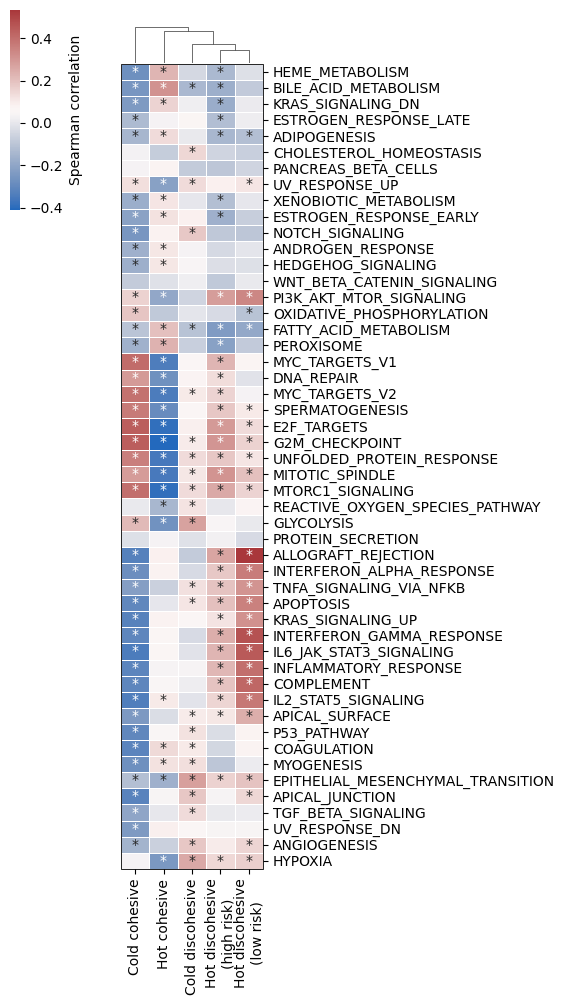

In [28]:
from matplotlib.patches import Rectangle

g = sns.clustermap(tcga_hallmarks_corr.T.loc[pathway_names_order],
               cmap='vlag',
               fmt='.2s',
               linewidth=.6,
               annot=annot_text.T.loc[pathway_names_order],
               row_cluster=False,
               dendrogram_ratio=(.2, .045), 
               colors_ratio=(0.05,0.07),
               cbar_pos=(-0.12, 0.80, 0.02, 0.2), 
               cbar_kws={'label':'Spearman correlation'},
               yticklabels=1,
               xticklabels=1,
               figsize=(5,10))

g.ax_heatmap.collections[0].set_edgecolor('white')
# g.ax_heatmap.collections[0].set_linewidth(.1)

n_rows, n_cols = change_data.T.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=.6,
    clip_on=False
)
g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.set_xlabel(None)

plt.savefig(os.path.join(main_path, 'analysis/rnaseq/TCGA_hallmarks.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)

### Cell counts

In [32]:
tcga_cell_counts = pd.read_csv(os.path.join(main_path, 'analysis/rnaseq/TCGA/MCP_Counter.csv'), index_col=0).T
tcga_cell_counts

,T cells,CD8 T cells,Cytotoxic lymphocytes,B lineage,NK cells,Monocytic lineage,Myeloid dendritic cells,Neutrophils,Endothelial cells,Fibroblasts
TCGA-05-4244,7.254619,7.118941,6.260384,7.718925,2.862573,10.711910,8.218502,8.685801,9.417564,12.859477
TCGA-05-4249,7.330207,6.918863,4.835910,10.149872,3.102246,10.850233,10.037412,8.978423,9.844106,13.184333
TCGA-05-4250,7.684396,8.927778,6.491788,7.857267,3.638491,10.609861,6.360352,8.175952,9.372602,14.693609
TCGA-05-4382,8.293910,7.257388,5.916549,10.512483,4.625639,12.079211,7.079457,8.838257,10.263243,15.498517
TCGA-05-4384,6.065026,5.321928,4.972240,6.988580,2.610521,10.239483,6.808730,9.404713,9.872700,11.694511
...,...,...,...,...,...,...,...,...,...,...
TCGA-NJ-A55O,6.525654,5.523562,4.346800,8.247728,3.290792,9.918060,7.258788,8.055831,9.577502,11.330202
TCGA-NJ-A55R,7.647643,5.459432,5.696051,12.087203,3.488290,10.527543,7.043614,8.975443,10.456486,14.446826
TCGA-NJ-A7XG,5.487465,4.247928,3.976485,7.544253,2.223883,7.729605,7.359040,7.719708,8.363152,10.856085
TCGA-O1-A52J,6.685762,5.357552,4.211779,6.849270,2.840084,10.167881,8.769179,7.870420,8.547147,12.101617


In [34]:
tcga_joint_cell_counts = tcga_rep_df.merge(tcga_cell_counts, left_index=True, right_index=True)
tcga_joint_cell_counts

,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)",T cells,CD8 T cells,Cytotoxic lymphocytes,B lineage,NK cells,Monocytic lineage,Myeloid dendritic cells,Neutrophils,Endothelial cells,Fibroblasts
TCGA-05-4250,3.367475,-1.750538,-1.065851,-1.268949,5.450559,7.684396,8.927778,6.491788,7.857267,3.638491,10.609861,6.360352,8.175952,9.372602,14.693609
TCGA-05-4382,-2.658130,0.626596,-3.473701,2.055745,11.881892,8.293910,7.257388,5.916549,10.512483,4.625639,12.079211,7.079457,8.838257,10.263243,15.498517
TCGA-05-4396,0.561612,-5.511588,2.233145,-1.065554,-3.752887,5.626307,4.000000,4.122072,6.674069,2.735521,8.790901,5.246325,7.643346,8.689049,11.232347
TCGA-05-4398,-1.272563,-4.115978,2.659374,-1.303408,3.901663,8.436759,7.894818,6.311508,10.483816,4.292620,12.008676,9.447095,9.066262,9.961598,14.663494
TCGA-05-4402,8.971970,1.000794,-1.609760,-1.353783,-5.820354,7.792429,6.754888,5.267127,10.576397,3.187754,11.328014,8.640007,8.917201,9.982432,14.484621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-NJ-A55O,-6.798068,-8.537535,8.273212,-1.422923,2.966509,6.525654,5.523562,4.346800,8.247728,3.290792,9.918060,7.258788,8.055831,9.577502,11.330202
TCGA-NJ-A55R,3.682602,-2.427294,-0.082256,1.189838,3.972421,7.647643,5.459432,5.696051,12.087203,3.488290,10.527543,7.043614,8.975443,10.456486,14.446826
TCGA-NJ-A7XG,-2.847957,-2.441106,-1.627404,-0.406851,9.357574,5.487465,4.247928,3.976485,7.544253,2.223883,7.729605,7.359040,7.719708,8.363152,10.856085
TCGA-O1-A52J,-0.762892,-7.216834,6.511597,-0.848187,-2.601247,6.685762,5.357552,4.211779,6.849270,2.840084,10.167881,8.769179,7.870420,8.547147,12.101617


In [36]:
cell_cols = tcga_cell_counts.columns

In [37]:
tcga_cell_counts_corr, _, p_vals = corr_mat(tcga_joint_cell_counts)

In [41]:
tcga_cell_counts_corr = tcga_cell_counts_corr.loc[cell_cols]
tcga_cell_counts_corr = tcga_cell_counts_corr[superclusters]

p_vals = p_vals.loc[cell_cols]
p_vals = p_vals[superclusters]

In [42]:
tcga_cell_counts_corr

,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)"
T cells,-0.262220,-0.215403,0.175423,0.128224,0.454849
CD8 T cells,-0.126551,-0.185654,0.052860,0.147589,0.422599
Cytotoxic lymphocytes,-0.160363,-0.159145,0.005477,0.248606,0.439694
B lineage,-0.252763,-0.196043,0.238075,-0.004336,0.382363
NK cells,-0.090638,-0.148276,-0.054203,0.230033,0.381962
Monocytic lineage,-0.141995,-0.001883,-0.025150,0.190372,0.316515
Myeloid dendritic cells,-0.402391,-0.061615,0.322672,-0.072891,0.120565
Neutrophils,-0.102190,-0.127328,0.115447,-0.119521,0.008074
Endothelial cells,-0.188513,-0.022182,0.125441,-0.121245,-0.022444
Fibroblasts,-0.085197,0.207099,-0.131942,0.094634,0.200487


In [44]:
significant_mask = p_vals < 0.05
annot_text = tcga_cell_counts_corr.applymap('{:.2f}'.format)
annot_text = annot_text.mask(significant_mask, '*')
annot_text = annot_text.mask(~significant_mask, ' ')
annot_text

/var/folders/r5/cz0g1khj0x31j72l145n8j880000gn/T/ipykernel_22495/3491647282.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = tcga_cell_counts_corr.applymap('{:.2f}'.format)


,"Cold, cohesive","Cold, discohesive","Hot, cohesive","Hot, discohesive (high risk)","Hot, discohesive (low risk)"
T cells,*,*,*,*,*
CD8 T cells,*,*,,*,*
Cytotoxic lymphocytes,*,*,,*,*
B lineage,*,*,*,,*
NK cells,,*,,*,*
Monocytic lineage,*,,,*,*
Myeloid dendritic cells,*,,*,,*
Neutrophils,*,*,*,*,
Endothelial cells,*,,*,*,
Fibroblasts,,*,*,,*


In [60]:
tcga_cell_counts_corr.columns = ['Cold cohesive', 'Cold discohesive', 'Hot cohesive', 'Hot discohesive\n(high risk)', 'Hot discohesive\n(low risk)']
p_vals.columns = ['Cold cohesive', 'Cold discohesive', 'Hot cohesive', 'Hot discohesive\n(high risk)', 'Hot discohesive\n(low risk)']

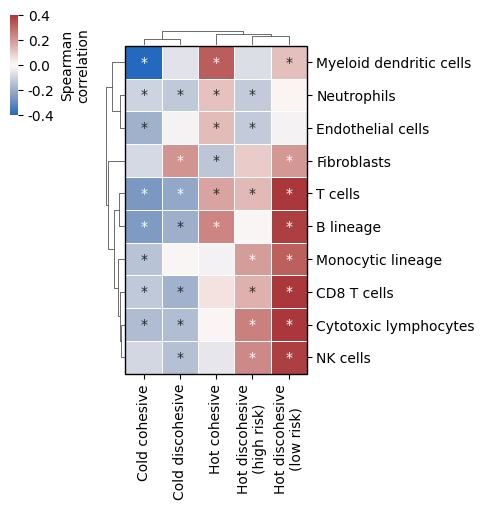

In [62]:
g = sns.clustermap(tcga_cell_counts_corr,
               cmap='vlag',
               vmin=-0.4,vmax=0.4,
               fmt='.2s',
               linewidth=.6,
               annot=annot_text,
               dendrogram_ratio=(.1, .045), 
               colors_ratio=(0.05,0.07),
               cbar_pos=(-0.2, 0.80, 0.02, 0.2), 
               cbar_kws={'label':'Spearman\ncorrelation'},
               yticklabels=1,
               xticklabels=1,
               figsize=(4,5))

g.ax_heatmap.collections[0].set_edgecolor('white')
# g.ax_heatmap.collections[0].set_linewidth(.1)

n_rows, n_cols = tcga_cell_counts_corr.shape

rect = Rectangle(
    xy=(0, 0),  # Lower left corner
    width=n_cols,
    height=n_rows,
    fill=False,
    edgecolor='black',
    linewidth=1,
    clip_on=False
)
g.ax_heatmap.add_patch(rect)
g.ax_heatmap.set_ylabel(None)
g.ax_heatmap.set_xlabel(None)

ticks = np.arange(-0.4, 0.41, 0.2)
g.cax.set_yticks(ticks)
g.cax.set_yticklabels([f"{t:.1f}" for t in ticks])

plt.savefig(os.path.join(main_path, 'analysis/rnaseq/TCGA_MCPCounter.pdf'), dpi=300, bbox_inches='tight', pad_inches=0.1)